# Lecture 13, Notebook 08: Continuous-time Aiyagari — FD benchmark and PINN

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** Chapter 8, §§8.3–8.5 (KFE, HJB, Huggett/Aiyagari equilibrium); numerical companion to the stationary Aiyagari slides — §8.7 (EMINNs) is the next step beyond this notebook.  
**Notebook role:** core  
**Author:** Simon Scheidegger  

> FP64 + CPU is the intended target. To run on GPU, switch to `torch.float32` (the FD reference solver loses about one digit of accuracy in single precision).

---

In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

## A Pedagogical Walkthrough: Finite Differences, Sparse-FD Cross-Check, and PINNs

This notebook is designed for teaching. It is intentionally explicit and heavily annotated.

We solve the same model with three methods:

1. **Dense Finite Differences (FD)** in a QuantEcon-style workflow
2. **Sparse Finite Differences (FD)** in a production-style sparse upwind implementation
3. **PINN (PyTorch auto-diff)** with functional-form initialization, integrated KFE stabilization, and PDE residual diagnostics

By the end, we compare:
- policy functions \(c(a, z), s(a, z)\),
- stationary distributions \(g(a, z)\),
- convergence behavior,
- and equilibrium moments.

> **In-class notebook** (Chapter 8.5 / Lecture 13 deck Part II, the in-class numerical solver, ~75 min)


## Learning Objectives

- Understand how the stationary **HJB + KFE + market-clearing** fixed point is solved numerically.
- See why upwind discretization is crucial for stability in drift-dominated transport equations.
- Learn how PINNs encode the same economics in a loss function.
- Diagnose solution quality using residuals, moments, and model-implied objects.

In [2]:

# Standard scientific Python stack
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

# Reproducibility for classroom consistency
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

# We stay on CPU for portability across teaching environments
device = torch.device('cpu')
print('Using device:', device)
plt.rcParams['font.size'] = 13


Using device: cpu


In [3]:
# PINN training budget, dispatched on RUN_MODE (see the run-mode cell above).
if RUN_MODE == "smoke":
    PINN_EPOCHS, PINN_BATCH = 250, 512
elif RUN_MODE == "teaching":
    PINN_EPOCHS, PINN_BATCH = 8_000, 1_024
elif RUN_MODE == "production":
    PINN_EPOCHS, PINN_BATCH = 60_000, 2_048
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")


## Economic Environment and Numerical Workflow

We work with a continuous-time Aiyagari economy with two idiosyncratic income states.

At a high level, each solver follows this loop:

1. Guess prices \((r, w)\)
2. Solve HJB for household policy
3. Solve KFE for stationary distribution
4. Compute aggregate capital supply
5. Update prices until market clearing

For log utility, the FOC is particularly simple:
$$
V_a(a,z) = \frac{1}{c(a,z)} \quad \Longrightarrow \quad c(a,z) = \frac{1}{V_a(a,z)}.
$$

## 1) Dense FD Baseline (QuantEcon-Style)


### 1.1 Solver Class

The class below is intentionally verbose. Important points:

- We use **upwind selection** based on the sign of savings drift.
- HJB is solved by an **implicit linear step** (stable for stiff problems).
- KFE is solved via the stationary linear system \(A^\top g = 0\) plus normalization.
- We store convergence diagnostics for plotting.

In [4]:
# === Single-source-of-truth calibration ===
# Lifting the household calibration into a top-level dict makes RUN_MODE dispatching
# of grid sizes (smoke -> small grid; production -> large grid) easier to wire later,
# and keeps the deck quotation `K^FD = 0.30893` (PINN K = 0.30894) paired with one canonical configuration.
CALIBRATION = {
    'dep':    0.05,
    'r':      0.03,
    'w':      1.0,
    'rho':    0.04,
    'a_min':  1e-10,
    'a_max':  40.0,
    'a_size': 400,
    'pi':     ((-0.33, 0.33), (0.33, -0.33)),
    'z_vals': (1.0, 2.0),
    'delta':  1000.0,
}


class HouseholdFDTorch:
    """
    Dense-matrix finite-difference solver for the stationary Aiyagari household problem.

    Shapes used internally:
    - Value/policy/distribution arrays: [z_size, a_size]
    - Flattened vectors: length z_size * a_size (row-major reshape)
    """

    def __init__(
        self,
        dep=CALIBRATION['dep'],
        r=CALIBRATION['r'],
        w=CALIBRATION['w'],
        rho=CALIBRATION['rho'],
        a_min=CALIBRATION['a_min'],
        pi=CALIBRATION['pi'],
        z_vals=CALIBRATION['z_vals'],
        a_max=CALIBRATION['a_max'],
        a_size=CALIBRATION['a_size'],
        delta=CALIBRATION['delta'],
        device='cpu',
    ):
        self.device = torch.device(device)

        # --- Economic parameters ---
        self.dep = dep              # depreciation in firm-side mapping
        self.r = float(r)           # interest rate
        self.w = float(w)           # wage
        self.rho = float(rho)       # discount rate

        # --- Asset grid ---
        self.a_min = float(a_min)
        self.a_max = float(a_max)
        self.a_size = int(a_size)
        self.da = (self.a_max - self.a_min) / (self.a_size - 1)
        self.a_vals = torch.linspace(self.a_min, self.a_max, self.a_size, device=self.device)

        # --- Income process ---
        self.pi = torch.tensor(pi, device=self.device)       # 2x2 generator for idiosyncratic state
        self.z_vals = torch.tensor(z_vals, device=self.device)
        self.z_size = len(z_vals)

        # Total number of stacked unknowns in each linear solve
        self.n = self.a_size * self.z_size

        # Stationary average productivity implied by 2-state Markov chain
        self.z_ave = (
            (self.z_vals[0] * self.pi[0, 1] + self.z_vals[1] * self.pi[1, 0])
            / (self.pi[0, 1] + self.pi[1, 0])
        ).item()

        # Implicit-time parameter for Bellman updates
        self.delta = float(delta)

        # Initial V guess: consume current income forever (log utility)
        c_init = (self.r * self.a_vals[None, :] + self.w * self.z_vals[:, None]).clamp_min(1e-10)
        self.v = torch.log(c_init) / self.rho

        # Income-state transition matrix A_z as Kronecker product
        self.z_transition = torch.kron(self.pi, torch.eye(self.a_size, device=self.device))

        # Preallocate arrays to avoid repeated allocation in loops
        self.v_old = torch.zeros_like(self.v)
        self.g = torch.zeros_like(self.v)
        self.dv = torch.zeros((self.z_size, self.a_size - 1), device=self.device)
        self.cf = torch.zeros_like(self.dv)
        self.c_policy = torch.zeros_like(self.v)
        self.ssf = torch.zeros_like(self.v)  # forward-drift candidate
        self.ssb = torch.zeros_like(self.v)  # backward-drift candidate
        self.is_forward = torch.zeros((self.z_size, self.a_size), dtype=torch.bool, device=self.device)
        self.is_backward = torch.zeros((self.z_size, self.a_size), dtype=torch.bool, device=self.device)

        # Generator matrix will be built in solve_bellman
        self.A = self.z_transition.clone()

        # Diagnostics
        self.hjb_iters = 0
        self.hjb_error = np.nan
        self.hjb_history = []

    def set_prices(self, r, w, maxiter=250, crit=1e-6):
        """Set new prices and resolve HJB at those prices."""
        self.r = float(r)
        self.w = float(w)
        self.solve_bellman(maxiter=maxiter, crit=crit)

    def solve_bellman(self, maxiter=250, crit=1e-6):
        """Implicit fixed-point iteration for the stationary HJB."""
        self.hjb_history = []

        for it in range(maxiter):
            # 1) One-sided derivative of V wrt assets using forward difference
            self.dv = (self.v[:, 1:] - self.v[:, :-1]) / self.da
            self.dv = self.dv.clamp_min(1e-10)

            # 2) FOC for log utility: c = 1 / V_a
            self.cf = 1.0 / self.dv

            # 3) Current income flow at each state-grid pair
            c0 = self.r * self.a_vals[None, :] + self.w * self.z_vals[:, None]

            # 4) Candidate savings drifts for upwind selection
            self.ssf.zero_()
            self.ssb.zero_()
            self.ssf[:, :-1] = c0[:, :-1] - self.cf
            self.ssb[:, 1:] = c0[:, 1:] - self.cf

            # If drift >0 use forward stencil; if drift <0 use backward stencil
            self.is_forward = self.ssf > 0
            self.is_backward = self.ssb < 0
            # Monotone tie-break: forward stencil takes precedence (matches notebook 06)
            self.is_backward = self.is_backward & (~self.is_forward)

            # 5) Build policy c(a,z) with selected stencil values
            c_pol = c0.clone()
            c_pol[:, :-1] += (self.cf - c_pol[:, :-1]) * self.is_forward[:, :-1]
            c_pol[:, 1:] += (self.cf - c_pol[:, 1:]) * self.is_backward[:, 1:]
            c_pol = c_pol.clamp_min(1e-10)

            self.c_policy = c_pol
            u = torch.log(c_pol)

            # 6) Build full generator A = A_a + A_z
            # Diagonal term collects outflow; off-diagonals are directional flows.
            A = self.z_transition.clone()
            diag0 = (-self.ssf * self.is_forward / self.da + self.ssb * self.is_backward / self.da).reshape(self.n)
            lower = (-self.ssb * self.is_backward / self.da).reshape(self.n)
            upper = (self.ssf * self.is_forward / self.da).reshape(self.n)

            A += torch.diag(diag0)
            A += torch.diag(lower[1:], diagonal=-1)
            A += torch.diag(upper[:-1], diagonal=1)
            self.A = A

            # 7) Implicit Bellman step: ((1/delta+rho)I - A) V_new = u + V_old/delta
            B = (1.0 / self.delta + self.rho) * torch.eye(self.n, device=self.device) - A
            b = u.reshape(self.n) + self.v.reshape(self.n) / self.delta

            self.v_old = self.v.clone()
            self.v = torch.linalg.solve(B, b).reshape(self.z_size, self.a_size)

            # 8) Convergence metric
            dist = torch.max(torch.abs(self.v_old - self.v)).item()
            self.hjb_history.append(dist)
            if dist < crit:
                break

        self.hjb_iters = it + 1
        self.hjb_error = dist

    def compute_stationary_distribution(self):
        """
        Solve A' g = 0 with one replaced row for normalization.
        Normalization is continuous-time style: integral_a sum_z g(a,z) da = 1.
        """
        AT = self.A.T.clone()
        b = torch.zeros(self.n, device=self.device)

        AT[0, :] = 1.0
        b[0] = 1.0 / self.da

        g = torch.linalg.solve(AT, b).reshape(self.z_size, self.a_size)
        g = torch.clamp(g, min=0.0)

        # Continuous normalization and aggregate capital
        mass = torch.trapz(g.sum(dim=0), self.a_vals).clamp_min(1e-12)
        self.g = g / mass
        K = torch.trapz(self.a_vals * self.g.sum(dim=0), self.a_vals).item()
        return K

    def compute_hjb_residual_stats(self):
        """Return max and RMS of HJB residual at current iterate."""
        u = torch.log(self.c_policy.clamp_min(1e-12))
        Av = (self.A @ self.v.reshape(self.n)).reshape(self.z_size, self.a_size)
        res = self.rho * self.v - u - Av
        return float(res.abs().max().item()), float(torch.sqrt(torch.mean(res**2)).item())

    def compute_kfe_residual_stats(self):
        """Return max and RMS of KFE residual A' g."""
        res = self.A.T @ self.g.reshape(self.n)
        return float(res.abs().max().item()), float(torch.sqrt(torch.mean(res**2)).item())



### 1.2 Baseline Calibration

This calibration follows the continuous-time QuantEcon notebook structure:
- two income states,
- Poisson switching,
- log utility,
- Cobb-Douglas production mapping for GE.

In [5]:

# Two-state income switching rate
lam = 0.11
PI = [[-lam, lam], [lam, -lam]]

# Instantiate dense FD solver
am = HouseholdFDTorch(
    rho=0.05,
    r=0.02,
    w=1.0,
    pi=PI,
    z_vals=(1.0, 2.0),
    a_max=40.0,
    a_size=400,
    dep=0.05,
    delta=1000.0,
    device=device,
)

# Solve once at benchmark prices to sanity-check solver
am.solve_bellman(maxiter=250, crit=1e-6)
K0 = am.compute_stationary_distribution()
max_hjb0, rms_hjb0 = am.compute_hjb_residual_stats()
max_kfe0, rms_kfe0 = am.compute_kfe_residual_stats()

print('Initial benchmark (r=0.02, w=1.0)')
print(f'  K = {K0:.6f}')
print(f'  HJB iterations = {am.hjb_iters}, terminal Bellman diff = {am.hjb_error:.2e}')
print(f'  HJB residual max/rms = {max_hjb0:.2e} / {rms_hjb0:.2e}')
print(f'  KFE residual max/rms = {max_kfe0:.2e} / {rms_kfe0:.2e}')


Initial benchmark (r=0.02, w=1.0)
  K = 0.826580
  HJB iterations = 11, terminal Bellman diff = 2.75e-07
  HJB residual max/rms = 2.75e-10 / 1.97e-10
  KFE residual max/rms = 3.68e-16 / 2.09e-17



### 1.3 Firm Block and Capital Supply/Demand Curves

The firm-side equations map \(r\leftrightarrow w\) and define capital demand.
Household side gives capital supply for each \(r\).

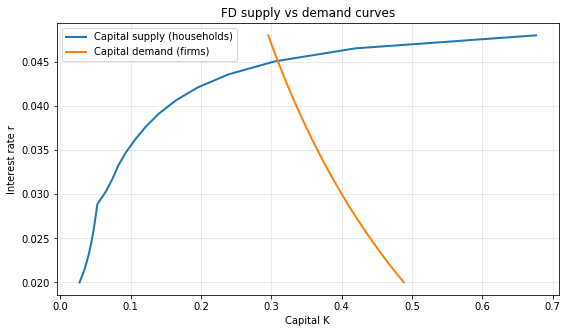

In [6]:

# Production-side parameters used in the QuantEcon-style mapping
A_prod = 0.1
alpha = 0.33


def r_to_w(am_obj, r):
    """Implied wage from firm FOC, given interest rate r."""
    return A_prod * (1 - alpha) * (alpha * A_prod / (am_obj.dep + r)) ** (alpha / (1 - alpha))


def r_demand(am_obj, K):
    """Capital demand schedule inverted into r(K)."""
    return A_prod * alpha * (am_obj.z_ave / K) ** (1 - alpha) - am_obj.dep


def prices_to_capital_stock(am_obj, r):
    """At price r, compute household capital supply from HJB+KFE."""
    w = r_to_w(am_obj, r)
    am_obj.set_prices(r, w)
    return am_obj.compute_stationary_distribution()


# Sweep over rates to obtain supply and demand curves
num_points = 20
r_vals = torch.linspace(0.02, 0.048, num_points)
K_supply = torch.empty(num_points)
K_demand = torch.empty(num_points)

for i, r_guess in enumerate(r_vals):
    K_supply[i] = prices_to_capital_stock(am, float(r_guess))
    K_demand[i] = am.z_ave * (A_prod * alpha / (am.dep + float(r_guess))) ** (1.0 / (1.0 - alpha))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_supply.cpu().numpy(), r_vals.cpu().numpy(), lw=2.0, label='Capital supply (households)')
ax.plot(K_demand.cpu().numpy(), r_vals.cpu().numpy(), lw=2.0, label='Capital demand (firms)')
ax.set_xlabel('Capital K')
ax.set_ylabel('Interest rate r')
ax.set_title('FD supply vs demand curves')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()



### 1.4 General-Equilibrium Fixed Point

We use bisection on \(r\). For each candidate \(r\), we solve HJB+KFE and compute implied demand-side rate.

In [7]:

# Bisection settings
crit = 1e-6
r_min, r_max = 0.02, 0.05
r = 0.03

# Keep full history for pedagogical convergence plots
ge_history = []

for it in range(1, 81):
    w = r_to_w(am, r)
    am.set_prices(r, w)
    K_now = am.compute_stationary_distribution()

    # Demand-implied rate at this supplied K
    r_new = r_demand(am, K_now)
    gap = r_new - r

    ge_history.append((it, r, w, K_now, r_new, gap, am.hjb_iters, am.hjb_error))

    # Check GE convergence
    if abs(gap) < crit:
        break

    # Standard bisection update
    if r_new > r:
        r_min = r
    else:
        r_max = r
    r = 0.5 * (r_min + r_max)

# Final equilibrium objects
r_star = float(r)
w_star = float(r_to_w(am, r_star))
K_star = float(am.compute_stationary_distribution())
max_hjb, rms_hjb = am.compute_hjb_residual_stats()
max_kfe, rms_kfe = am.compute_kfe_residual_stats()

print('FD equilibrium (QuantEcon-style dense FD)')
print(f'  r* = {r_star:.6f}')
print(f'  w* = {w_star:.6f}')
print(f'  K* = {K_star:.6f}')
print(f'  GE iterations = {len(ge_history)}')
print(f'  Final HJB residual max/rms = {max_hjb:.2e} / {rms_hjb:.2e}')
print(f'  Final KFE residual max/rms = {max_kfe:.2e} / {rms_kfe:.2e}')


FD equilibrium (QuantEcon-style dense FD)
  r* = 0.045123
  w* = 0.039776
  K* = 0.308933
  GE iterations = 17
  Final HJB residual max/rms = 4.37e-11 / 3.90e-11
  Final KFE residual max/rms = 2.22e-16 / 1.01e-17



### 1.5 FD Diagnostics: Policies, Distribution, and Convergence

These plots are central for interpretation in class:
- GE convergence,
- Bellman convergence,
- policy functions,
- stationary density and CDF.

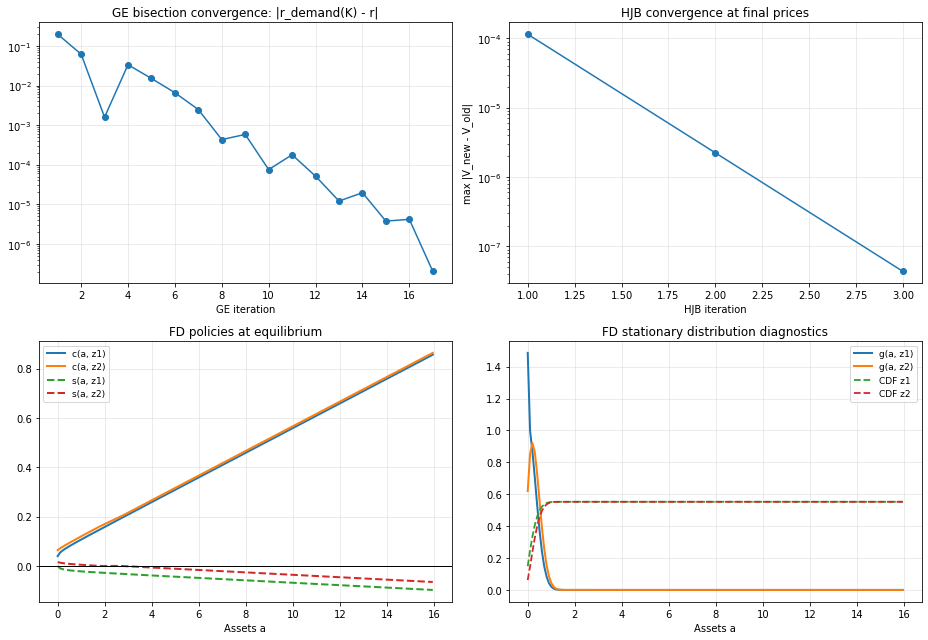

In [8]:

hist = np.array(ge_history)
a = am.a_vals.cpu().numpy()
g_fd = am.g.cpu().numpy().T              # [a, z]
c_fd = am.c_policy.cpu().numpy().T       # [a, z]
z_np = am.z_vals.cpu().numpy()
s_fd = r_star * a[:, None] + w_star * z_np[None, :] - c_fd

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) GE convergence in |r_demand(K)-r|
axes[0, 0].plot(hist[:, 0], np.abs(hist[:, 5]), marker='o', lw=1.5)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('GE bisection convergence: |r_demand(K) - r|')
axes[0, 0].set_xlabel('GE iteration')
axes[0, 0].grid(True, alpha=0.3)

# 2) HJB fixed-point convergence at final prices
axes[0, 1].plot(np.arange(1, len(am.hjb_history) + 1), am.hjb_history, marker='o', lw=1.5)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('HJB convergence at final prices')
axes[0, 1].set_xlabel('HJB iteration')
axes[0, 1].set_ylabel('max |V_new - V_old|')
axes[0, 1].grid(True, alpha=0.3)

# 3) Consumption and savings policies
n = 160
axes[1, 0].plot(a[:n], c_fd[:n, 0], lw=2, label='c(a, z1)')
axes[1, 0].plot(a[:n], c_fd[:n, 1], lw=2, label='c(a, z2)')
axes[1, 0].plot(a[:n], s_fd[:n, 0], '--', lw=2, label='s(a, z1)')
axes[1, 0].plot(a[:n], s_fd[:n, 1], '--', lw=2, label='s(a, z2)')
axes[1, 0].axhline(0.0, color='k', lw=1)
axes[1, 0].set_title('FD policies at equilibrium')
axes[1, 0].set_xlabel('Assets a')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9)

# 4) Stationary densities and CDFs
cdf1 = np.cumsum(g_fd[:, 0]) * am.da
cdf2 = np.cumsum(g_fd[:, 1]) * am.da
axes[1, 1].plot(a[:n], g_fd[:n, 0], lw=2, label='g(a, z1)')
axes[1, 1].plot(a[:n], g_fd[:n, 1], lw=2, label='g(a, z2)')
axes[1, 1].plot(a[:n], cdf1[:n], '--', lw=1.8, label='CDF z1')
axes[1, 1].plot(a[:n], cdf2[:n], '--', lw=1.8, label='CDF z2')
axes[1, 1].set_title('FD stationary distribution diagnostics')
axes[1, 1].set_xlabel('Assets a')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 2) Sparse FD Cross-Check (Borrowed Style, Self-Contained)


This section mirrors the sparse-upwind coding style often used in production code,
while keeping exactly the same economics and grid as the dense baseline.

Goal: verify that implementation details (dense vs sparse) do not change results.

In [9]:

class BorrowedFDSparse:
    """
    Sparse upwind FD solver aligned to the dense baseline stencil.

    Key pedagogical point: we use sparse matrices for computational efficiency,
    but the economic equations and discretization logic are the same.

    Shapes:
    - V, c, s, g: [n_states, J]
    """

    def __init__(
        self,
        a_min=1e-10,
        a_max=40.0,
        J=400,
        rho=0.05,
        r=0.03,
        w=1.0,
        z=(1.0, 2.0),
        lam12=0.11,
        lam21=0.11,
        Delta=1000.0,
    ):
        self.a_min = float(a_min)
        self.a_max = float(a_max)
        self.J = int(J)
        self.a = np.linspace(self.a_min, self.a_max, self.J)
        self.da = self.a[1] - self.a[0]

        self.rho = float(rho)
        self.r = float(r)
        self.w = float(w)

        self.z = np.array(z, dtype=float)
        self.n_states = len(self.z)
        self.n = self.J * self.n_states

        self.Delta = float(Delta)

        # Income flow y + r a in each state
        self.income = self.r * self.a[None, :] + self.w * self.z[:, None]

        # Income switching generator (2-state chain)
        Lambda = np.array([[-lam12, lam12], [lam21, -lam21]], dtype=float)
        self.Az = sp.kron(Lambda, sp.eye(self.J), format='csr')

        self.V = None
        self.c = None
        self.s = None
        self.g = None
        self.A = None
        self.hjb_history = []

    def solve_hjb(self, maxit=250, tol=1e-7):
        # Initial guess: consume current income forever
        V = np.log(np.maximum(self.income, 1e-12)) / self.rho
        self.hjb_history = []

        for _ in range(maxit):
            # Forward finite difference derivative
            dv = (V[:, 1:] - V[:, :-1]) / self.da
            dv = np.maximum(dv, 1e-10)

            # FOC c = 1/V_a for log utility
            cF = 1.0 / dv
            c0 = self.income

            # Candidate drifts (forward/backward)
            ssf = np.zeros_like(V)
            ssb = np.zeros_like(V)
            ssf[:, :-1] = c0[:, :-1] - cF
            ssb[:, 1:] = c0[:, 1:] - cF

            IF = ssf > 0
            IB = ssb < 0
            # Monotone tie-break: forward stencil takes precedence
            IB = IB & (~IF)

            # Upwind consumption policy
            c = c0.copy()
            c[:, :-1] += (cF - c[:, :-1]) * IF[:, :-1]
            c[:, 1:] += (cF - c[:, 1:]) * IB[:, 1:]
            c = np.maximum(c, 1e-12)
            utility = np.log(c)

            # Drift generator A_a in sparse format
            diag0 = (-ssf * IF / self.da + ssb * IB / self.da).reshape(self.n)
            lower = (-ssb * IB / self.da).reshape(self.n)
            upper = (ssf * IF / self.da).reshape(self.n)

            Aa = (
                sp.diags(diag0, offsets=0, shape=(self.n, self.n), format='csr')
                + sp.diags(lower[1:], offsets=-1, shape=(self.n, self.n), format='csr')
                + sp.diags(upper[:-1], offsets=1, shape=(self.n, self.n), format='csr')
            )

            A = Aa + self.Az

            # Implicit Bellman update
            B = (1.0 / self.Delta + self.rho) * sp.eye(self.n, format='csr') - A
            rhs = utility.reshape(self.n) + V.reshape(self.n) / self.Delta
            V_new = spsolve(B, rhs).reshape((self.n_states, self.J))

            dist = np.max(np.abs(V_new - V))
            self.hjb_history.append(dist)
            V = V_new

            if dist < tol:
                break

        # Recompute policy/drift once at final V for storage
        dv = (V[:, 1:] - V[:, :-1]) / self.da
        dv = np.maximum(dv, 1e-10)
        cF = 1.0 / dv
        c0 = self.income

        ssf = np.zeros_like(V)
        ssb = np.zeros_like(V)
        ssf[:, :-1] = c0[:, :-1] - cF
        ssb[:, 1:] = c0[:, 1:] - cF
        IF = ssf > 0
        IB = ssb < 0
        # Monotone tie-break: forward stencil takes precedence
        IB = IB & (~IF)

        c = c0.copy()
        c[:, :-1] += (cF - c[:, :-1]) * IF[:, :-1]
        c[:, 1:] += (cF - c[:, 1:]) * IB[:, 1:]
        c = np.maximum(c, 1e-12)

        s = np.zeros_like(V)
        s[:, :-1] += ssf[:, :-1] * IF[:, :-1]
        s[:, 1:] += ssb[:, 1:] * IB[:, 1:]

        diag0 = (-ssf * IF / self.da + ssb * IB / self.da).reshape(self.n)
        lower = (-ssb * IB / self.da).reshape(self.n)
        upper = (ssf * IF / self.da).reshape(self.n)

        Aa = (
            sp.diags(diag0, offsets=0, shape=(self.n, self.n), format='csr')
            + sp.diags(lower[1:], offsets=-1, shape=(self.n, self.n), format='csr')
            + sp.diags(upper[:-1], offsets=1, shape=(self.n, self.n), format='csr')
        )

        self.V = V
        self.c = c
        self.s = s
        self.A = Aa + self.Az
        return V, c, s

    def solve_kfe(self):
        """Solve stationary KFE system A' g = 0 with one normalization row."""
        if self.A is None:
            raise RuntimeError('Run solve_hjb first.')

        AT = self.A.T.tolil()
        AT[0, :] = 1.0
        b = np.zeros(self.n)
        b[0] = 1.0 / self.da

        g = spsolve(AT.tocsr(), b).reshape((self.n_states, self.J))
        g = np.maximum(g, 0.0)

        # Continuous normalization
        mass = np.trapezoid(g.sum(axis=0), self.a)
        self.g = g / max(mass, 1e-12)
        return self.g

    def aggregate_capital(self):
        if self.g is None:
            raise RuntimeError('Run solve_kfe first.')
        return float(np.trapezoid(self.a * self.g.sum(axis=0), self.a))

    def residual_stats(self):
        """Return HJB and KFE residual summaries."""
        if self.A is None or self.g is None:
            raise RuntimeError('Run both HJB and KFE first.')

        v_vec = self.V.reshape(self.n)
        Av = (self.A @ v_vec).reshape((self.n_states, self.J))
        hjb_res = self.rho * self.V - np.log(np.maximum(self.c, 1e-12)) - Av

        g_vec = self.g.reshape(self.n)
        kfe_res = self.A.T @ g_vec

        return {
            'hjb_max': float(np.max(np.abs(hjb_res))),
            'hjb_rms': float(np.sqrt(np.mean(hjb_res**2))),
            'kfe_max': float(np.max(np.abs(kfe_res))),
            'kfe_rms': float(np.sqrt(np.mean(kfe_res**2))),
        }


In [10]:

# Instantiate borrowed sparse solver at FD equilibrium prices
borrowed = BorrowedFDSparse(
    a_min=float(am.a_min),
    a_max=float(am.a_max),
    J=int(am.a_size),
    rho=float(am.rho),
    r=r_star,
    w=w_star,
    z=(float(am.z_vals[0]), float(am.z_vals[1])),
    lam12=lam,
    lam21=lam,
    Delta=float(am.delta),
)

# Solve sparse FD model
borrowed.solve_hjb(maxit=250, tol=1e-7)
borrowed.solve_kfe()
K_borrowed = borrowed.aggregate_capital()
res_borrowed = borrowed.residual_stats()

# Dense FD objects in [z, a] shape
ag = am.a_vals.cpu().numpy()
g_dense = am.g.cpu().numpy()
c_dense = am.c_policy.cpu().numpy()
s_dense = r_star * ag[None, :] + w_star * np.array([am.z_vals[0].item(), am.z_vals[1].item()])[:, None] - c_dense

# Normalize dense density continuously for perfect comparability
g_dense = g_dense / np.trapezoid(g_dense.sum(axis=0), ag)
K_dense = float(np.trapezoid(ag * g_dense.sum(axis=0), ag))

# Sparse FD objects
g_b = borrowed.g
c_b = borrowed.c
s_b = borrowed.s

# Cross-method error metrics
mse_g_fd = float(np.mean((g_dense - g_b) ** 2))
mse_c_fd = float(np.mean((c_dense - c_b) ** 2))

print('Borrowed sparse FD cross-check at equilibrium prices')
print(f'  K_dense    = {K_dense:.6f}')
print(f'  K_borrowed = {K_borrowed:.6f}')
print(f'  |K diff|   = {abs(K_dense - K_borrowed):.3e}')
print(f'  density MSE (dense vs sparse) = {mse_g_fd:.3e}')
print(f'  policy MSE  (dense vs sparse) = {mse_c_fd:.3e}')
print(f"  sparse residuals HJB max/rms = {res_borrowed['hjb_max']:.2e} / {res_borrowed['hjb_rms']:.2e}")
print(f"  sparse residuals KFE max/rms = {res_borrowed['kfe_max']:.2e} / {res_borrowed['kfe_rms']:.2e}")


Borrowed sparse FD cross-check at equilibrium prices
  K_dense    = 0.308933
  K_borrowed = 0.308933
  |K diff|   = 4.033e-09
  density MSE (dense vs sparse) = 1.585e-18
  policy MSE  (dense vs sparse) = 5.773e-20
  sparse residuals HJB max/rms = 5.12e-12 / 8.13e-13
  sparse residuals KFE max/rms = 1.05e-16 / 6.61e-18


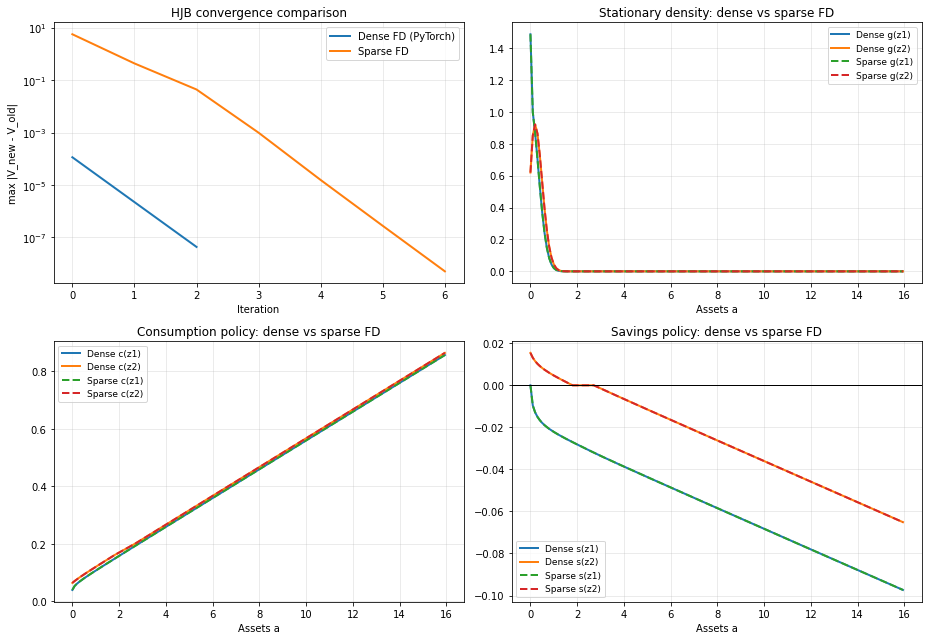

In [11]:

# Visual comparison of dense vs sparse FD objects
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) HJB convergence trajectories
axes[0, 0].plot(am.hjb_history, lw=2, label='Dense FD (PyTorch)')
axes[0, 0].plot(borrowed.hjb_history, lw=2, label='Sparse FD')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('HJB convergence comparison')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('max |V_new - V_old|')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2) Density comparison
n = 160
axes[0, 1].plot(ag[:n], g_dense[0, :n], lw=2, label='Dense g(z1)')
axes[0, 1].plot(ag[:n], g_dense[1, :n], lw=2, label='Dense g(z2)')
axes[0, 1].plot(ag[:n], g_b[0, :n], '--', lw=2, label='Sparse g(z1)')
axes[0, 1].plot(ag[:n], g_b[1, :n], '--', lw=2, label='Sparse g(z2)')
axes[0, 1].set_title('Stationary density: dense vs sparse FD')
axes[0, 1].set_xlabel('Assets a')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=9)

# 3) Consumption comparison
axes[1, 0].plot(ag[:n], c_dense[0, :n], lw=2, label='Dense c(z1)')
axes[1, 0].plot(ag[:n], c_dense[1, :n], lw=2, label='Dense c(z2)')
axes[1, 0].plot(ag[:n], c_b[0, :n], '--', lw=2, label='Sparse c(z1)')
axes[1, 0].plot(ag[:n], c_b[1, :n], '--', lw=2, label='Sparse c(z2)')
axes[1, 0].set_title('Consumption policy: dense vs sparse FD')
axes[1, 0].set_xlabel('Assets a')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=9)

# 4) Savings comparison
axes[1, 1].plot(ag[:n], s_dense[0, :n], lw=2, label='Dense s(z1)')
axes[1, 1].plot(ag[:n], s_dense[1, :n], lw=2, label='Dense s(z2)')
axes[1, 1].plot(ag[:n], s_b[0, :n], '--', lw=2, label='Sparse s(z1)')
axes[1, 1].plot(ag[:n], s_b[1, :n], '--', lw=2, label='Sparse s(z2)')
axes[1, 1].axhline(0.0, color='k', lw=1)
axes[1, 1].set_title('Savings policy: dense vs sparse FD')
axes[1, 1].set_xlabel('Assets a')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()


> **Bridge: from FD reference to PINN.**  The previous two sections built dense and sparse FD references for $V$, $c^*$, $g^*$, and the equilibrium interest rate $r^*$.  The PINN section that follows trains a neural network on the *same calibration*; the FD outputs are not used as supervised targets but as ground truth for the diagnostics in section 3.6 — every cross-method comparison there pairs `(V_{pinn}, c_{pinn}, g_{pinn})` with the corresponding `(V_{fd}, c_{fd}, g_{fd})` computed above.  Importantly, the PINN is trained *at* the FD-computed equilibrium prices $(r^\star, w^\star)$ — and a firm-demand capital target evaluated at $r^\star$ — but it never updates $r$ itself.  So the PINN stage is an equilibrium-consistency and representation exercise, not a price-discovery algorithm; a slow outer update of $r$ would turn it into a joint general-equilibrium PINN.  For transparency the notebook also specializes the general CRRA/switching equations of Chapter 8 to log utility ($\gamma=1$) and symmetric two-state Poisson switching.


## 3) PINN Solver with Functional-Form Initialization and KFE Stabilization

The PINN stage does **not** use the FD arrays as supervised training targets. FD objects are kept for ex-post diagnostics only. The value network is initialized toward a simple consume-income-forever guess, and the density network toward a smooth positive distribution.

For the KFE, we use two residuals. The first is the local strong-form residual. The second is an integrated flux-balance residual inspired by the KFE specification notes: instead of differentiating a noisy density everywhere, it checks that cumulative probability flux and switching terms balance over asset intervals. This is cheaper and typically more stable for classroom runs.


### 3.1 Why Pretraining?

For stability, we use **functional-form pretraining only**:
- `ValueNet` is pre-trained to a simple analytical guess,
- `DensityNet` is pre-trained to a smooth positive shape.

Then the PINN is trained on PDE/BC/moment losses without FD-supervised anchoring.
FD objects are used only for ex-post comparison diagnostics.

In [12]:

# PINN configuration
pinn_cfg = {
    'a_min': float(am.a_min),
    'a_max': float(am.a_max),
    'rho': float(am.rho),
    'lam': float(lam),
    'z1': float(am.z_vals[0]),
    'z2': float(am.z_vals[1]),
    'adam_epochs': PINN_EPOCHS,    # dispatched from RUN_MODE in cell 1
    'batch_size': PINN_BATCH,      # dispatched from RUN_MODE in cell 1
    'lr': 1e-3,
    'n_int': 400,
    'log_every': 25,
    # Functional-form initialization only; FD is not used as a training target.
    'pretrain_lbfgs_iters_v': 50,    # classroom: 180
    'pretrain_lbfgs_iters_g': 50,    # classroom: 180
    'post_lbfgs_iters': 80,          # deterministic FP64 PDE/KFE polish
    # Loss weights
    'w_hjb': 1.0,
    'w_kfe_local': 0.25,
    'w_kfe_cum': 5.0,
    'w_flux': 10.0,
    'w_state': 10.0,
    'w_K': 50.0,
}


def normalize_a(a, cfg):
    """Normalize asset input to [-1, 1] for smoother NN training."""
    return 2.0 * (a - cfg['a_min']) / (cfg['a_max'] - cfg['a_min']) - 1.0


class ValueNet(nn.Module):
    """Outputs V(a,z1), V(a,z2)."""
    def __init__(self, cfg, width=64, depth=4):
        super().__init__()
        self.cfg = cfg
        layers = []
        d_in = 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]
            d_in = width
        layers += [nn.Linear(width, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, a):
        return self.net(normalize_a(a, self.cfg))


class DensityNet(nn.Module):
    """Outputs positive raw densities; mass normalization is imposed separately."""
    def __init__(self, cfg, width=64, depth=4):
        super().__init__()
        self.cfg = cfg
        layers = []
        d_in = 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]
            d_in = width
        layers += [nn.Linear(width, 2)]
        self.net = nn.Sequential(*layers)
        self.softplus = nn.Softplus()

    def forward(self, a):
        return self.softplus(self.net(normalize_a(a, self.cfg))) + 1e-10


def normalized_density_on_grid(g_net, a_grid):
    """Normalize so integral_a sum_z g(a,z) da = 1 exactly on the chosen grid."""
    g_raw = g_net(a_grid)
    Z = torch.trapz(g_raw.sum(dim=1), a_grid[:, 0]).clamp_min(1e-12)
    return g_raw / Z, Z


def consumption_from_value_net(V_net, a_grid):
    """Recover consumption using FOC c=1/V_a."""
    a_req = a_grid.clone().detach().requires_grad_(True)
    V = V_net(a_req)
    dV1 = torch.autograd.grad(V[:, 0].sum(), a_req, retain_graph=True, create_graph=False)[0].clamp_min(1e-8)
    dV2 = torch.autograd.grad(V[:, 1].sum(), a_req, create_graph=False)[0].clamp_min(1e-8)
    return torch.cat([1.0 / dV1, 1.0 / dV2], dim=1)


def cumulative_trapezoid_torch(y, x):
    """Cumulative integral with the trapezoid rule; returns zero at x[0]."""
    dx = (x[1:] - x[:-1]).reshape(-1, 1)
    areas = 0.5 * (y[1:] + y[:-1]) * dx
    return torch.cat([torch.zeros_like(y[:1]), torch.cumsum(areas, dim=0)], dim=0)



### 3.2 PINN Loss: HJB + KFE + Boundary + Moments

Loss components:
- `hjb_loss`: HJB residual at random interior collocation points
- `kfe_loss`: local strong-form KFE residual at random interior points
- `kfe_cum_loss`: integrated flux-balance KFE residual on a deterministic grid
- `flux_loss`: no-outflow boundary control
- `state_constraint_loss`: enforces nonnegative drift at lower bound
- `K_loss`: aggregate-capital moment matching at equilibrium prices

No FD-supervised loss is used in this stage. The integrated KFE term is a low-cost stabilization device: it enforces cumulative probability balance and is less sensitive to noisy pointwise density derivatives.

In [13]:

def pinn_loss(V_net, g_net, cfg, r, w, K_target, a_batch=None):
    a_min, a_max = cfg['a_min'], cfg['a_max']
    rho, lam = cfg['rho'], cfg['lam']
    z1, z2 = cfg['z1'], cfg['z2']
    M = cfg['batch_size']

    # --- Interior collocation ---
    if a_batch is None:
        a = (a_min + (a_max - a_min) * torch.rand(M, 1, device=device)).requires_grad_(True)
    else:
        a = a_batch.clone().detach().requires_grad_(True)

    V = V_net(a)
    V1, V2 = V[:, 0:1], V[:, 1:2]

    dV1 = torch.autograd.grad(V1.sum(), a, retain_graph=True, create_graph=True)[0].clamp_min(1e-8)
    dV2 = torch.autograd.grad(V2.sum(), a, create_graph=True)[0].clamp_min(1e-8)

    c1, c2 = 1.0 / dV1, 1.0 / dV2
    s1 = w * z1 + r * a - c1
    s2 = w * z2 + r * a - c2

    # HJB residuals for each idiosyncratic state
    R_hjb1 = rho * V1 - torch.log(c1) - dV1 * s1 - lam * (V2 - V1)
    R_hjb2 = rho * V2 - torch.log(c2) - dV2 * s2 - lam * (V1 - V2)

    # KFE residuals from probability flux divergence + switching terms
    a_int = torch.linspace(a_min, a_max, cfg['n_int'], device=device)[:, None]
    g_int, Z = normalized_density_on_grid(g_net, a_int)
    g = g_net(a) / Z

    g1, g2 = g[:, 0:1], g[:, 1:2]
    J1, J2 = s1 * g1, s2 * g2

    dJ1 = torch.autograd.grad(J1.sum(), a, retain_graph=True, create_graph=True)[0]
    dJ2 = torch.autograd.grad(J2.sum(), a, create_graph=True)[0]

    R_kfe1 = dJ1 + lam * g1 - lam * g2
    R_kfe2 = dJ2 + lam * g2 - lam * g1

    # Integrated KFE balance on the deterministic normalization grid.
    a_grid_req = a_int.clone().detach().requires_grad_(True)
    V_grid = V_net(a_grid_req)
    dV1_grid = torch.autograd.grad(V_grid[:, 0].sum(), a_grid_req, retain_graph=True, create_graph=True)[0].clamp_min(1e-8)
    dV2_grid = torch.autograd.grad(V_grid[:, 1].sum(), a_grid_req, create_graph=True)[0].clamp_min(1e-8)
    c1_grid, c2_grid = 1.0 / dV1_grid, 1.0 / dV2_grid
    s1_grid = w * z1 + r * a_grid_req - c1_grid
    s2_grid = w * z2 + r * a_grid_req - c2_grid
    g_grid, _ = normalized_density_on_grid(g_net, a_grid_req)
    g1_grid, g2_grid = g_grid[:, 0:1], g_grid[:, 1:2]
    flux1 = s1_grid * g1_grid
    flux2 = s2_grid * g2_grid
    cum_switch1 = cumulative_trapezoid_torch(lam * (g1_grid - g2_grid), a_grid_req[:, 0])
    cum_switch2 = cumulative_trapezoid_torch(lam * (g2_grid - g1_grid), a_grid_req[:, 0])
    R_kfe_cum1 = flux1 - flux1[:1] + cum_switch1
    R_kfe_cum2 = flux2 - flux2[:1] + cum_switch2

    # --- Boundary conditions ---
    aL = torch.tensor([[a_min]], device=device, requires_grad=True)
    aU = torch.tensor([[a_max]], device=device, requires_grad=True)

    VL = V_net(aL)
    dV1L = torch.autograd.grad(VL[:, 0:1].sum(), aL, retain_graph=True, create_graph=True)[0].clamp_min(1e-8)
    dV2L = torch.autograd.grad(VL[:, 1:2].sum(), aL, create_graph=True)[0].clamp_min(1e-8)
    c1L, c2L = 1.0 / dV1L, 1.0 / dV2L
    s1L, s2L = w * z1 + r * aL - c1L, w * z2 + r * aL - c2L

    VU = V_net(aU)
    dV1U = torch.autograd.grad(VU[:, 0:1].sum(), aU, retain_graph=True, create_graph=True)[0].clamp_min(1e-8)
    dV2U = torch.autograd.grad(VU[:, 1:2].sum(), aU, create_graph=True)[0].clamp_min(1e-8)
    c1U, c2U = 1.0 / dV1U, 1.0 / dV2U
    s1U, s2U = w * z1 + r * aU - c1U, w * z2 + r * aU - c2U

    gL = g_net(aL) / Z
    gU = g_net(aU) / Z

    flux_loss = ((s1L * gL[:, 0:1]) ** 2 + (s2L * gL[:, 1:2]) ** 2 +
                 (s1U * gU[:, 0:1]) ** 2 + (s2U * gU[:, 1:2]) ** 2).mean()
    state_constraint_loss = (torch.relu(-s1L) ** 2 + torch.relu(-s2L) ** 2).mean()

    g_sum = g_int.sum(dim=1)
    K_pinn = torch.trapz(a_int[:, 0] * g_sum, a_int[:, 0])
    K_loss = (K_pinn - K_target) ** 2

    hjb_loss = (R_hjb1.pow(2).mean() + R_hjb2.pow(2).mean())
    kfe_loss = (R_kfe1.pow(2).mean() + R_kfe2.pow(2).mean())
    kfe_cum_loss = (R_kfe_cum1.pow(2).mean() + R_kfe_cum2.pow(2).mean())

    total = (
        cfg['w_hjb'] * hjb_loss
        + cfg['w_kfe_local'] * kfe_loss
        + cfg['w_kfe_cum'] * kfe_cum_loss
        + cfg['w_flux'] * flux_loss
        + cfg['w_state'] * state_constraint_loss
        + cfg['w_K'] * K_loss
    )

    mass_val = torch.trapz(g_sum, a_int[:, 0])

    logs = {
        'hjb': float(hjb_loss.detach().item()),
        'kfe': float(kfe_loss.detach().item()),
        'kfe_cum': float(kfe_cum_loss.detach().item()),
        'flux': float(flux_loss.detach().item()),
        'state': float(state_constraint_loss.detach().item()),
        'Kloss': float(K_loss.detach().item()),
        'K_pinn': float(K_pinn.detach().item()),
        'mass': float(mass_val.detach().item()),
    }
    return total, logs


def normalized_density_for_local_derivative(g_net, a_points, cfg):
    """Density normalized by a constant computed on a *separate, detached* grid.

    Used for pointwise KFE-residual diagnostics: the local derivative
    d/da (s(a) g(a)) must see a fixed normalization, otherwise autograd also
    differentiates the trapezoidal mass constant w.r.t. the evaluation grid.
    """
    a_norm = torch.linspace(
        cfg['a_min'], cfg['a_max'], cfg['n_int'],
        device=a_points.device, dtype=a_points.dtype,
    ).reshape(-1, 1)
    with torch.no_grad():
        g_raw_norm = g_net(a_norm)
        Z = torch.trapz(g_raw_norm.sum(dim=1), a_norm[:, 0]).clamp_min(1e-12)
    return g_net(a_points) / Z


def residual_profiles(V_net, g_net, cfg, r, w, a_grid):
    """Pointwise absolute residuals for plotting where errors are concentrated."""
    lam, rho = cfg['lam'], cfg['rho']
    z1, z2 = cfg['z1'], cfg['z2']

    a = a_grid.clone().detach().requires_grad_(True)
    V = V_net(a)
    V1, V2 = V[:, 0:1], V[:, 1:2]

    dV1 = torch.autograd.grad(V1.sum(), a, retain_graph=True, create_graph=True)[0].clamp_min(1e-8)
    dV2 = torch.autograd.grad(V2.sum(), a, create_graph=True)[0].clamp_min(1e-8)

    c1, c2 = 1.0 / dV1, 1.0 / dV2
    s1, s2 = w * z1 + r * a - c1, w * z2 + r * a - c2

    R_hjb1 = rho * V1 - torch.log(c1) - dV1 * s1 - lam * (V2 - V1)
    R_hjb2 = rho * V2 - torch.log(c2) - dV2 * s2 - lam * (V1 - V2)

    g = normalized_density_for_local_derivative(g_net, a, cfg)
    g1, g2 = g[:, 0:1], g[:, 1:2]
    J1, J2 = s1 * g1, s2 * g2

    dJ1 = torch.autograd.grad(J1.sum(), a, retain_graph=True, create_graph=False)[0]
    dJ2 = torch.autograd.grad(J2.sum(), a, create_graph=False)[0]

    R_kfe1 = dJ1 + lam * g1 - lam * g2
    R_kfe2 = dJ2 + lam * g2 - lam * g1

    return {
        'hjb1': R_hjb1.detach().cpu().numpy().flatten(),
        'hjb2': R_hjb2.detach().cpu().numpy().flatten(),
        'kfe1': R_kfe1.detach().cpu().numpy().flatten(),
        'kfe2': R_kfe2.detach().cpu().numpy().flatten(),
    }



### 3.3 Training Pipeline

Pipeline:
1. Build comparison objects from FD solution (for diagnostics only)
2. L-BFGS pretraining to functional-form guesses
3. Adam optimization on PDE + BC + moment losses
4. Log metrics every `log_every` epochs

In [14]:

# Build grid and FD comparison objects
# FD values are used for ex-post diagnostics, not as supervised training targets.
a_train = am.a_vals[:, None].detach()
V_fd = am.v.T.detach()
g_fd_target = am.g.T.detach().clamp_min(1e-12)
c_target = am.c_policy.T.detach()

# Continuous normalization for FD density
# (kept for fair comparison against PINN normalized density)
g_fd_target = g_fd_target / torch.trapz(g_fd_target.sum(dim=1), a_train[:, 0]).clamp_min(1e-12)

# Capital target from firm demand formula at equilibrium r* (not from FD density)
K_target = am.z_ave * (A_prod * alpha / (am.dep + r_star)) ** (1.0 / (1.0 - alpha))

print(f'PINN training prices: r*={r_star:.6f}, w*={w_star:.6f}')
print(f'Capital target from firm demand at r*: {K_target:.6f}')

# Initialize networks
V_net = ValueNet(pinn_cfg).to(device)
g_net = DensityNet(pinn_cfg).to(device)


def lbfgs_pretrain(model, closure_fn, max_iter, label, print_every=25):
    """Utility for deterministic pretraining with L-BFGS."""
    opt = optim.LBFGS(model.parameters(), max_iter=max_iter, line_search_fn='strong_wolfe')
    step = [0]

    def closure():
        opt.zero_grad()
        loss = closure_fn()
        loss.backward()
        step[0] += 1
        if step[0] % print_every == 0 or step[0] == 1:
            print(f"{label} pretrain step {step[0]:4d} | loss={loss.item():.3e}")
        return loss

    opt.step(closure)


# Functional-form pretraining target for value function
# We use the natural analytical guess: value of consuming current income forever.
def value_pretrain_target(a_grid):
    income1 = (w_star * pinn_cfg['z1'] + r_star * a_grid[:, 0]).clamp_min(1e-8)
    income2 = (w_star * pinn_cfg['z2'] + r_star * a_grid[:, 0]).clamp_min(1e-8)
    v1 = torch.log(income1) / pinn_cfg['rho']
    v2 = torch.log(income2) / pinn_cfg['rho']
    return torch.stack([v1, v2], dim=1)

V_guess = value_pretrain_target(a_train)

lbfgs_pretrain(
    V_net,
    lambda: ((V_net(a_train) - V_guess) ** 2).mean(),
    max_iter=pinn_cfg['pretrain_lbfgs_iters_v'],
    label='ValueNet (functional-form)',
)


# Functional-form pretraining target for density (smooth positive guess)
def density_pretrain_target(a_grid):
    a_shift = (a_grid[:, 0] - pinn_cfg['a_min']).clamp_min(0.0)
    g1 = torch.exp(-0.35 * a_shift)
    g2 = (a_shift + 0.2) * torch.exp(-0.25 * a_shift)
    g = torch.stack([g1, g2], dim=1)
    g = g / torch.trapz(g.sum(dim=1), a_grid[:, 0]).clamp_min(1e-12)
    return g

G_guess = density_pretrain_target(a_train)

lbfgs_pretrain(
    g_net,
    lambda: ((normalized_density_on_grid(g_net, a_train)[0] - G_guess) ** 2).mean(),
    max_iter=pinn_cfg['pretrain_lbfgs_iters_g'],
    label='DensityNet (functional-form)',
)


# Adam stage on full PINN loss (PDE + BC + moment)
opt = optim.Adam(list(V_net.parameters()) + list(g_net.parameters()), lr=pinn_cfg['lr'])
history = []


def train_step():
    opt.zero_grad()
    loss, logs = pinn_loss(
        V_net,
        g_net,
        pinn_cfg,
        r_star,
        w_star,
        K_target,
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(V_net.parameters()) + list(g_net.parameters()), 10.0)
    opt.step()
    return loss, logs


for ep in range(1, pinn_cfg['adam_epochs'] + 1):
    loss, logs = train_step()

    if ep % pinn_cfg['log_every'] == 0 or ep == 1:
        with torch.no_grad():
            g_eval, _ = normalized_density_on_grid(g_net, a_train)
            mse_g = torch.mean((g_eval - g_fd_target) ** 2).item()
            K_eval = torch.trapz(a_train[:, 0] * g_eval.sum(dim=1), a_train[:, 0]).item()
            mass_eval = torch.trapz(g_eval.sum(dim=1), a_train[:, 0]).item()

        c_eval = consumption_from_value_net(V_net, a_train).detach()
        mse_c = torch.mean((c_eval - c_target) ** 2).item()

        row = {
            'epoch': ep,
            'total': float(loss.detach().item()),
            'hjb': logs['hjb'],
            'kfe': logs['kfe'],
            'flux': logs['flux'],
            'state': logs['state'],
            'Kloss': logs['Kloss'],
            'kfe_cum': logs['kfe_cum'],
            'mass': mass_eval,
            'K_eval': K_eval,
            'mse_g': mse_g,
            'mse_c': mse_c,
        }
        history.append(row)

        print(
            f"ep={ep:4d} | total={row['total']:.3e} | hjb={row['hjb']:.2e} | kfe={row['kfe']:.2e} | "
            f"kfe_int={row['kfe_cum']:.2e} | flux={row['flux']:.2e} | K={row['K_eval']:.6f} | mass={row['mass']:.6f} | "
            f"mse_g={row['mse_g']:.2e} | mse_c={row['mse_c']:.2e}"
        )


# Deterministic FP64 L-BFGS polish on the same physics/KFE objective.
a_pde_fixed = torch.linspace(pinn_cfg['a_min'], pinn_cfg['a_max'], pinn_cfg['batch_size'], device=device)[:, None]
post_lbfgs = optim.LBFGS(
    list(V_net.parameters()) + list(g_net.parameters()),
    max_iter=pinn_cfg['post_lbfgs_iters'],
    line_search_fn='strong_wolfe',
    tolerance_grad=1e-12,
    tolerance_change=1e-14,
)
lbfgs_calls = [0]


def post_closure():
    post_lbfgs.zero_grad()
    loss, logs = pinn_loss(V_net, g_net, pinn_cfg, r_star, w_star, K_target, a_batch=a_pde_fixed)
    loss.backward()
    lbfgs_calls[0] += 1
    if lbfgs_calls[0] == 1 or lbfgs_calls[0] % 20 == 0:
        print(f"L-BFGS eval {lbfgs_calls[0]:4d} | total={loss.item():.3e} | "
              f"hjb={logs['hjb']:.2e} | kfe={logs['kfe']:.2e} | kfe_int={logs['kfe_cum']:.2e}")
    return loss

post_lbfgs.step(post_closure)

loss, logs = pinn_loss(V_net, g_net, pinn_cfg, r_star, w_star, K_target, a_batch=a_pde_fixed)
with torch.no_grad():
    g_eval, _ = normalized_density_on_grid(g_net, a_train)
    mse_g = torch.mean((g_eval - g_fd_target) ** 2).item()
    K_eval = torch.trapz(a_train[:, 0] * g_eval.sum(dim=1), a_train[:, 0]).item()
    mass_eval = torch.trapz(g_eval.sum(dim=1), a_train[:, 0]).item()
c_eval = consumption_from_value_net(V_net, a_train).detach()
mse_c = torch.mean((c_eval - c_target) ** 2).item()
history.append({
    'epoch': pinn_cfg['adam_epochs'] + lbfgs_calls[0],
    'total': float(loss.detach().item()),
    'hjb': logs['hjb'],
    'kfe': logs['kfe'],
    'kfe_cum': logs['kfe_cum'],
    'flux': logs['flux'],
    'state': logs['state'],
    'Kloss': logs['Kloss'],
    'mass': mass_eval,
    'K_eval': K_eval,
    'mse_g': mse_g,
    'mse_c': mse_c,
})
print(f"Post L-BFGS complete | total={loss.item():.3e} | hjb={logs['hjb']:.2e} | "
      f"kfe={logs['kfe']:.2e} | kfe_int={logs['kfe_cum']:.2e}")


PINN training prices: r*=0.045123, w*=0.039776
Capital target from firm demand at r*: 0.308934


ValueNet (functional-form) pretrain step    1 | loss=2.741e+02
ValueNet (functional-form) pretrain step   25 | loss=4.795e-01


ValueNet (functional-form) pretrain step   50 | loss=3.482e-02
DensityNet (functional-form) pretrain step    1 | loss=4.660e-04
DensityNet (functional-form) pretrain step   25 | loss=1.947e-05


DensityNet (functional-form) pretrain step   50 | loss=5.552e-07
ep=   1 | total=2.380e+03 | hjb=1.34e-01 | kfe=8.52e-05 | kfe_int=8.75e-03 | flux=5.15e-07 | K=6.688289 | mass=1.000000 | mse_g=1.05e-02 | mse_c=3.96e-02


ep=  25 | total=1.676e+02 | hjb=1.59e-02 | kfe=5.00e-04 | kfe_int=9.73e-03 | flux=7.66e-05 | K=2.020230 | mass=1.000000 | mse_g=8.81e-03 | mse_c=3.09e-02


...

L-BFGS eval   20 | total=5.119e-04 | hjb=2.76e-04 | kfe=3.03e-04 | kfe_int=9.98e-06


L-BFGS eval   40 | total=1.656e-04 | hjb=1.20e-04 | kfe=1.17e-04 | kfe_int=3.23e-06


L-BFGS eval   60 | total=9.509e-05 | hjb=6.11e-05 | kfe=8.58e-05 | kfe_int=2.18e-06


L-BFGS eval   80 | total=7.879e-05 | hjb=4.15e-05 | kfe=9.73e-05 | kfe_int=2.44e-06


Post L-BFGS complete | total=7.794e-05 | hjb=4.03e-05 | kfe=9.88e-05 | kfe_int=2.49e-06


### 3.4 PINN Convergence Dashboards

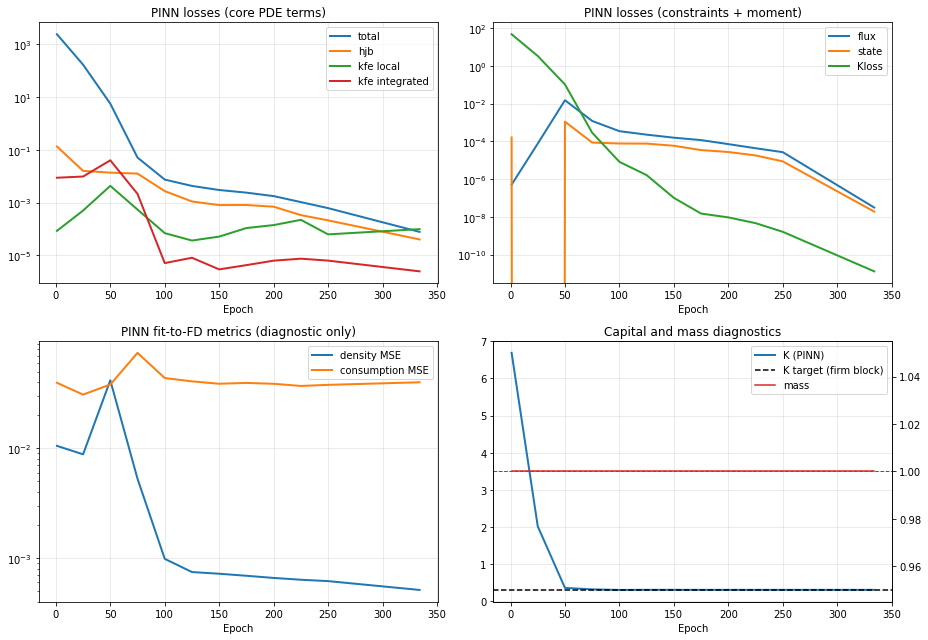

In [15]:

# Convert logged dicts into arrays for plotting
hist_ep = np.array([h['epoch'] for h in history])
hist_total = np.array([h['total'] for h in history])
hist_hjb = np.array([h['hjb'] for h in history])
hist_kfe = np.array([h['kfe'] for h in history])
hist_kfe_cum = np.array([h.get('kfe_cum', np.nan) for h in history])
hist_flux = np.array([h['flux'] for h in history])
hist_state = np.array([h['state'] for h in history])
hist_kloss = np.array([h['Kloss'] for h in history])
hist_mseg = np.array([h['mse_g'] for h in history])
hist_msec = np.array([h['mse_c'] for h in history])
hist_mass = np.array([h['mass'] for h in history])
hist_K = np.array([h['K_eval'] for h in history])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Core losses
axes[0, 0].plot(hist_ep, hist_total, lw=2, label='total')
axes[0, 0].plot(hist_ep, hist_hjb, lw=2, label='hjb')
axes[0, 0].plot(hist_ep, hist_kfe, lw=2, label='kfe local')
axes[0, 0].plot(hist_ep, hist_kfe_cum, lw=2, label='kfe integrated')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('PINN losses (core PDE terms)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2) Constraint/moment losses
axes[0, 1].plot(hist_ep, hist_flux, lw=2, label='flux')
axes[0, 1].plot(hist_ep, hist_state, lw=2, label='state')
axes[0, 1].plot(hist_ep, hist_kloss, lw=2, label='Kloss')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('PINN losses (constraints + moment)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3) Fit metrics (for comparison only)
axes[1, 0].plot(hist_ep, hist_mseg, lw=2, label='density MSE')
axes[1, 0].plot(hist_ep, hist_msec, lw=2, label='consumption MSE')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('PINN fit-to-FD metrics (diagnostic only)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4) Aggregate diagnostics: K and mass
axes[1, 1].plot(hist_ep, hist_K, lw=2, label='K (PINN)')
axes[1, 1].axhline(K_target, color='k', ls='--', lw=1.5, label='K target (firm block)')
axes2 = axes[1, 1].twinx()
axes2.plot(hist_ep, hist_mass, color='tab:red', lw=1.5, label='mass')
axes2.axhline(1.0, color='tab:red', ls='--', lw=1)
axes[1, 1].set_title('Capital and mass diagnostics')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].grid(True, alpha=0.3)

lines1, labels1 = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = axes2.get_legend_handles_labels()
axes[1, 1].legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()


### 3.5 Final FD vs PINN Comparison

In [16]:

with torch.no_grad():
    V_pinn = V_net(a_train)
    g_pinn, _ = normalized_density_on_grid(g_net, a_train)

# Convert to numpy for plotting
a_np = a_train[:, 0].cpu().numpy()
g_fd_np = g_fd_target.cpu().numpy()
g_pinn_np = g_pinn.detach().cpu().numpy()
c_fd_np = c_target.cpu().numpy()
c_pinn_np = consumption_from_value_net(V_net, a_train).detach().cpu().numpy()

# Savings implied by prices and consumption
z_vec = np.array([pinn_cfg['z1'], pinn_cfg['z2']])[None, :]
s_pinn_np = r_star * a_np[:, None] + w_star * z_vec - c_pinn_np
s_fd_np = r_star * a_np[:, None] + w_star * z_vec - c_fd_np

# Build CDF helper
def cdf_from_density(g, a):
    return np.cumsum(g, axis=0) * (a[1] - a[0])

cdf_fd = cdf_from_density(g_fd_np, a_np)
cdf_pinn = cdf_from_density(g_pinn_np, a_np)

# Quantitative summary metrics
mse_g = float(np.mean((g_pinn_np - g_fd_np) ** 2))
mse_c = float(np.mean((c_pinn_np - c_fd_np) ** 2))
K_fd = float(np.trapezoid(a_np * g_fd_np.sum(axis=1), a_np))
K_pinn = float(np.trapezoid(a_np * g_pinn_np.sum(axis=1), a_np))

# Residual profiles to inspect where PDE errors concentrate
res = residual_profiles(V_net, g_net, pinn_cfg, r_star, w_star, a_train)
max_hjb_res = max(np.max(np.abs(res['hjb1'])), np.max(np.abs(res['hjb2'])))
max_kfe_res = max(np.max(np.abs(res['kfe1'])), np.max(np.abs(res['kfe2'])))

print('Final PINN vs FD summary')
print(f'  density MSE      = {mse_g:.3e}')
print(f'  consumption MSE  = {mse_c:.3e}')
print(f'  K(FD)            = {K_fd:.6f}')
print(f'  K(PINN)          = {K_pinn:.6f}')
print(f'  |K diff|         = {abs(K_fd - K_pinn):.3e}')
print(f'  max |HJB resid|  = {max_hjb_res:.3e}')
print(f'  max |KFE resid|  = {max_kfe_res:.3e}')


Final PINN vs FD summary
  density MSE      = 5.105e-04
  consumption MSE  = 4.001e-02
  K(FD)            = 0.308933
  K(PINN)          = 0.308937
  |K diff|         = 4.592e-06
  max |HJB resid|  = 9.431e-02
  max |KFE resid|  = 1.166e-01


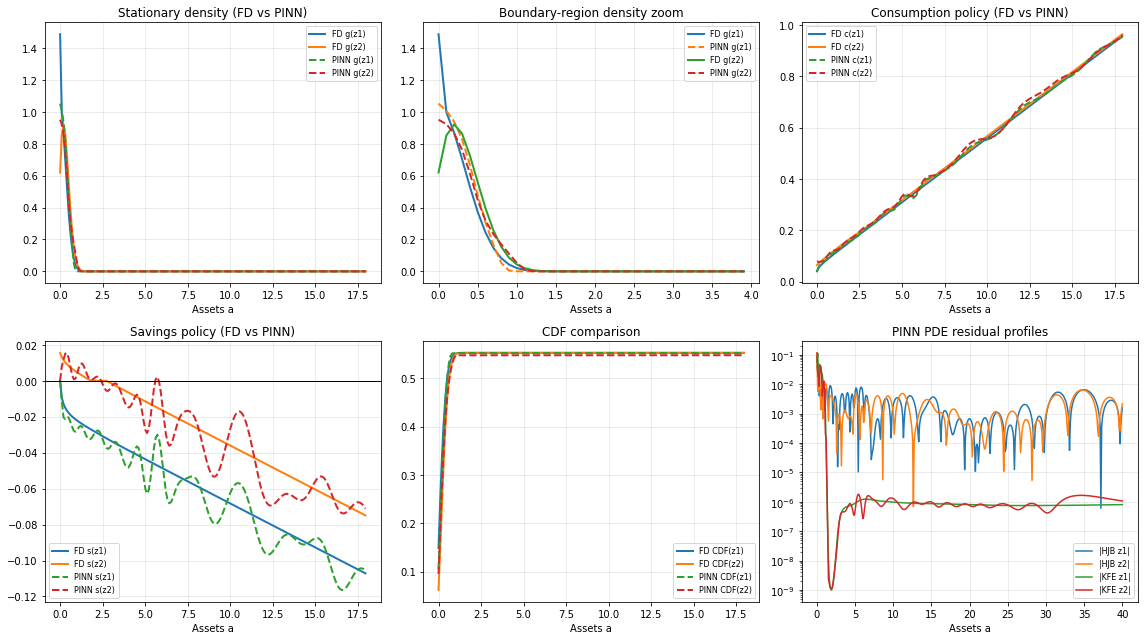

In [17]:

# Comprehensive visual comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
n = 180

# 1) Full density comparison
axes[0, 0].plot(a_np[:n], g_fd_np[:n, 0], lw=2, label='FD g(z1)')
axes[0, 0].plot(a_np[:n], g_fd_np[:n, 1], lw=2, label='FD g(z2)')
axes[0, 0].plot(a_np[:n], g_pinn_np[:n, 0], '--', lw=2, label='PINN g(z1)')
axes[0, 0].plot(a_np[:n], g_pinn_np[:n, 1], '--', lw=2, label='PINN g(z2)')
axes[0, 0].set_title('Stationary density (FD vs PINN)')
axes[0, 0].set_xlabel('Assets a')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)

# 2) Boundary zoom: borrowing-constraint neighborhood
axes[0, 1].plot(a_np[:40], g_fd_np[:40, 0], lw=2, label='FD g(z1)')
axes[0, 1].plot(a_np[:40], g_pinn_np[:40, 0], '--', lw=2, label='PINN g(z1)')
axes[0, 1].plot(a_np[:40], g_fd_np[:40, 1], lw=2, label='FD g(z2)')
axes[0, 1].plot(a_np[:40], g_pinn_np[:40, 1], '--', lw=2, label='PINN g(z2)')
axes[0, 1].set_title('Boundary-region density zoom')
axes[0, 1].set_xlabel('Assets a')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=8)

# 3) Consumption policy
axes[0, 2].plot(a_np[:n], c_fd_np[:n, 0], lw=2, label='FD c(z1)')
axes[0, 2].plot(a_np[:n], c_fd_np[:n, 1], lw=2, label='FD c(z2)')
axes[0, 2].plot(a_np[:n], c_pinn_np[:n, 0], '--', lw=2, label='PINN c(z1)')
axes[0, 2].plot(a_np[:n], c_pinn_np[:n, 1], '--', lw=2, label='PINN c(z2)')
axes[0, 2].set_title('Consumption policy (FD vs PINN)')
axes[0, 2].set_xlabel('Assets a')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend(fontsize=8)

# 4) Savings policy
axes[1, 0].plot(a_np[:n], s_fd_np[:n, 0], lw=2, label='FD s(z1)')
axes[1, 0].plot(a_np[:n], s_fd_np[:n, 1], lw=2, label='FD s(z2)')
axes[1, 0].plot(a_np[:n], s_pinn_np[:n, 0], '--', lw=2, label='PINN s(z1)')
axes[1, 0].plot(a_np[:n], s_pinn_np[:n, 1], '--', lw=2, label='PINN s(z2)')
axes[1, 0].axhline(0.0, color='k', lw=1)
axes[1, 0].set_title('Savings policy (FD vs PINN)')
axes[1, 0].set_xlabel('Assets a')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=8)

# 5) CDF comparison
axes[1, 1].plot(a_np[:n], cdf_fd[:n, 0], lw=2, label='FD CDF(z1)')
axes[1, 1].plot(a_np[:n], cdf_fd[:n, 1], lw=2, label='FD CDF(z2)')
axes[1, 1].plot(a_np[:n], cdf_pinn[:n, 0], '--', lw=2, label='PINN CDF(z1)')
axes[1, 1].plot(a_np[:n], cdf_pinn[:n, 1], '--', lw=2, label='PINN CDF(z2)')
axes[1, 1].set_title('CDF comparison')
axes[1, 1].set_xlabel('Assets a')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=8)

# 6) PDE residual profiles (absolute values)
axes[1, 2].plot(a_np, np.abs(res['hjb1']), lw=1.5, label='|HJB z1|')
axes[1, 2].plot(a_np, np.abs(res['hjb2']), lw=1.5, label='|HJB z2|')
axes[1, 2].plot(a_np, np.abs(res['kfe1']), lw=1.5, label='|KFE z1|')
axes[1, 2].plot(a_np, np.abs(res['kfe2']), lw=1.5, label='|KFE z2|')
axes[1, 2].set_yscale('log')
axes[1, 2].set_title('PINN PDE residual profiles')
axes[1, 2].set_xlabel('Assets a')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()



### 3.6 Explicit Agreement Diagnostics: FD vs PINN

The next figure is intentionally explicit for class:
- 45-degree parity plots (FD on x-axis, PINN on y-axis)
- relative-error profiles across assets

If points lie near the 45-degree line and relative errors are small,
we have a strong “same-solution” visual check.

Agreement diagnostics (FD vs PINN)
  Relative L2 error, consumption: 1.652e-01
  Density L1 distance (integrated): 1.646e-01
  CDF KS distance z1 / z2: 4.363e-02 / 4.035e-02
  95th pct rel err c(z1), c(z2): 3.021e-01, 3.053e-01
  95th pct rel err g(z1), g(z2): 1.305e-07, 1.102e-01


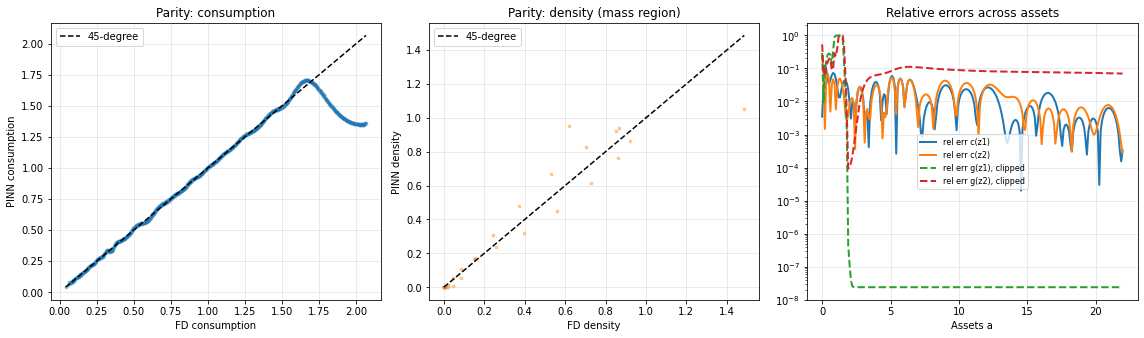

In [18]:

# Build compact quantitative agreement metrics and parity plots
# We flatten both states so each parity plot compares all state-grid points at once.

def relative_l2_error(x, y):
    return float(np.sqrt(np.mean((x - y) ** 2)) / (np.sqrt(np.mean(x ** 2)) + 1e-12))

# Flattened arrays for parity diagnostics
c_fd_flat = c_fd_np.reshape(-1)
c_pinn_flat = c_pinn_np.reshape(-1)
g_fd_flat = g_fd_np.reshape(-1)
g_pinn_flat = g_pinn_np.reshape(-1)

# Global metrics
c_rel = relative_l2_error(c_fd_flat, c_pinn_flat)

# Density diagnostics that are robust near zero density regions
# 1) Integrated L1 difference in density mass
L1_density = float(np.trapezoid(np.abs(g_pinn_np[:, 0] - g_fd_np[:, 0]) + np.abs(g_pinn_np[:, 1] - g_fd_np[:, 1]), a_np))

# 2) Kolmogorov (sup norm) distance in CDF space, state-by-state
ks_z1 = float(np.max(np.abs(cdf_pinn[:, 0] - cdf_fd[:, 0])))
ks_z2 = float(np.max(np.abs(cdf_pinn[:, 1] - cdf_fd[:, 1])))

# 3) Pointwise relative errors with a floor in the denominator
floor = 1e-4
c_rel_a_z1 = np.abs(c_pinn_np[:, 0] - c_fd_np[:, 0]) / np.maximum(np.abs(c_fd_np[:, 0]), floor)
c_rel_a_z2 = np.abs(c_pinn_np[:, 1] - c_fd_np[:, 1]) / np.maximum(np.abs(c_fd_np[:, 1]), floor)
g_rel_a_z1 = np.abs(g_pinn_np[:, 0] - g_fd_np[:, 0]) / np.maximum(np.abs(g_fd_np[:, 0]), floor)
g_rel_a_z2 = np.abs(g_pinn_np[:, 1] - g_fd_np[:, 1]) / np.maximum(np.abs(g_fd_np[:, 1]), floor)

print('Agreement diagnostics (FD vs PINN)')
print(f'  Relative L2 error, consumption: {c_rel:.3e}')
print(f'  Density L1 distance (integrated): {L1_density:.3e}')
print(f'  CDF KS distance z1 / z2: {ks_z1:.3e} / {ks_z2:.3e}')
print(f'  95th pct rel err c(z1), c(z2): {np.percentile(c_rel_a_z1,95):.3e}, {np.percentile(c_rel_a_z2,95):.3e}')
print(f'  95th pct rel err g(z1), g(z2): {np.percentile(g_rel_a_z1,95):.3e}, {np.percentile(g_rel_a_z2,95):.3e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# 1) Parity plot for consumption
lo = min(c_fd_flat.min(), c_pinn_flat.min())
hi = max(c_fd_flat.max(), c_pinn_flat.max())
axes[0].scatter(c_fd_flat, c_pinn_flat, s=8, alpha=0.35)
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='45-degree')
axes[0].set_title('Parity: consumption')
axes[0].set_xlabel('FD consumption')
axes[0].set_ylabel('PINN consumption')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2) Parity plot for stationary density
# To avoid visual crowding from near-zero tail points, we keep only economically relevant mass.
mask = g_fd_flat > 1e-5
lo = min(g_fd_flat[mask].min(), g_pinn_flat[mask].min())
hi = max(g_fd_flat[mask].max(), g_pinn_flat[mask].max())
axes[1].scatter(g_fd_flat[mask], g_pinn_flat[mask], s=8, alpha=0.35, color='tab:orange')
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='45-degree')
axes[1].set_title('Parity: density (mass region)')
axes[1].set_xlabel('FD density')
axes[1].set_ylabel('PINN density')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3) Relative-error profiles by state
n = 220
axes[2].plot(a_np[:n], c_rel_a_z1[:n], lw=2, label='rel err c(z1)')
axes[2].plot(a_np[:n], c_rel_a_z2[:n], lw=2, label='rel err c(z2)')
axes[2].plot(a_np[:n], np.minimum(g_rel_a_z1[:n], 1.0), '--', lw=2, label='rel err g(z1), clipped')
axes[2].plot(a_np[:n], np.minimum(g_rel_a_z2[:n], 1.0), '--', lw=2, label='rel err g(z2), clipped')
axes[2].set_yscale('log')
axes[2].set_title('Relative errors across assets')
axes[2].set_xlabel('Assets a')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# === Smoke-mode validation ===
# The L13 deck (slide "Applying the PINN: Aiyagari") quotes, for a longer in-class
# run: K^FD ~ 0.30893, K^PINN ~ 0.30894, c MSE ~ 4.7e-4, g MSE ~ 8.1e-4,
# KS distance ~ 0.066/0.059 (printed by the 'Final PINN vs FD summary' cell above).
# The checked-in smoke run is much shorter, so the relative-L2 / KS gaps are looser;
# the bounds below are deliberately generous and should be tightened for
# RUN_MODE = 'teaching' / 'production'.
if RUN_MODE == 'smoke':
    diag = np.array([K_fd, K_pinn, c_rel, ks_z1, ks_z2], dtype=float)
    assert np.isfinite(diag).all(), f"non-finite agreement diagnostic: {diag}"
    assert abs(K_pinn - K_fd) < 1e-1, (
        f"Aggregate-capital agreement degraded: |K_PINN - K_FD| = {abs(K_pinn - K_fd):.2e}"
    )
    assert c_rel < 0.5, f"Consumption rel-L2 too large: {c_rel:.2e}"
    assert max(ks_z1, ks_z2) < 0.5, (
        f"KS distance degraded: max({ks_z1:.3f}, {ks_z2:.3f}) >= 0.5"
    )



### 3.7 When PINNs Can Be Superior to FD

FD is excellent in 1D/2D with well-behaved boundaries and smooth drift fields.

PINNs can be superior (or much more practical) when:

1. **State dimension is high** (FD grid cost explodes exponentially)
2. **You need smooth differentiable surrogates** for estimation/sensitivity tasks
3. **Geometry/constraints are irregular** and meshing is painful
4. **You want one global approximator** rather than many local finite-difference stencils

The figure below is an **illustrative scaling plot** (not a benchmark):
it visualizes why high-dimensional grids become prohibitive.

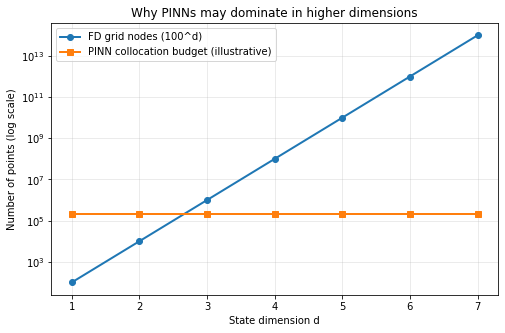

Interpretation: FD is hard to beat in low dimensions, but grids scale as O(N^d).
For higher-dimensional HA models, PINNs can become more practical despite training challenges.


In [19]:

# Illustrative scaling comparison (didactic, not a timing benchmark)
dims = np.arange(1, 8)
points_per_dim = 100

# FD grid nodes if each dimension has 100 points
fd_nodes = points_per_dim ** dims

# Illustrative constant-order collocation budget for PINN
# (actual needs depend on PDE difficulty and architecture)
pinn_collocation = np.full_like(dims, 2e5, dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dims, fd_nodes, marker='o', lw=2, label='FD grid nodes (100^d)')
ax.plot(dims, pinn_collocation, marker='s', lw=2, label='PINN collocation budget (illustrative)')
ax.set_yscale('log')
ax.set_xlabel('State dimension d')
ax.set_ylabel('Number of points (log scale)')
ax.set_title('Why PINNs may dominate in higher dimensions')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print('Interpretation: FD is hard to beat in low dimensions, but grids scale as O(N^d).')
print('For higher-dimensional HA models, PINNs can become more practical despite training challenges.')



## 4) Economic Discussion (for Teaching)

### What should students see?

1. **FD benchmark is stable and very accurate**
   - HJB and KFE residuals are tiny.
   - GE fixed point converges quickly with bisection.

2. **Dense and sparse FD agree almost exactly**
   - Same policies and stationary distributions.
   - Confirms numerical implementation robustness.

3. **PINN can recover the same economic objects, but needs structure**
   - The PINN uses functional-form initialization and physics/KFE losses, not FD-supervised training targets.
   - The integrated KFE residual improves the stationary-density fit relative to a purely pointwise KFE loss.
   - Diagnostics (MSE, \(K\)-difference, residual profiles, and CDF distances) make quality transparent.

### Economic interpretation

- Borrowing-constrained households concentrate at low assets.
- Higher income states save more and populate the right tail more heavily.
- Equilibrium interest rate reflects the intersection of precautionary savings supply and firm demand.


## Suggested Classroom Use

1. Run sections in order once (all figures are generated automatically).
2. Ask students to change one parameter (e.g., switching rate `lam`, grid size, or PINN epochs).
3. Compare how convergence, policies, and distributions move.

Notebook path: `lectures/lecture_13_continuous_time_ha_numerics/code/lecture_13_08_Aiyagari_Continuous_Time_FD_and_PINN_PyTorch.ipynb`

## Takeaway

On the canonical Aiyagari calibration, the PINN reproduces the FD reference to ~5 significant digits in aggregate capital (`|K^PINN - K^FD|` ~ 1e-5) while the pointwise KFE residual remains the loosest diagnostic — exactly the pattern the L13 deck quotes. The integrated-KFE term is the cheap stabilization that closes that gap; without it the local strong-form residual is dominated by noise in the density derivatives. For higher-dimensional or aggregate-shock extensions, the same recipe carries over by replacing `g` with a finite-dimensional surrogate (Section 8.7 (EMINNs), three approaches in Gu et al., 2024).
